<a href="https://colab.research.google.com/github/nikhilkanse2596/LINEAR-REGRESSION-HANDSON/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("https://drive.google.com/uc?id=1n5sNB5DVsTGSFlD5AVMcTzNlPf_CeiyT")

In [6]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [8]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [9]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [10]:
df.isnull().sum().sum()

np.int64(52)

In [11]:
df.duplicated().sum()

np.int64(0)

# **REPLACING VALUES**

In [12]:
# df['age'].fillna(df['age'].median(), inplace=True)

In [13]:
for x in df.columns:
    if df[x].dtype == 'float64':
        df[x] = df[x].fillna(df[x].mean())
    else:
        df[x] = df[x].fillna(df[x].mode()[0])

In [14]:
df.isnull().sum().sum()

np.int64(0)

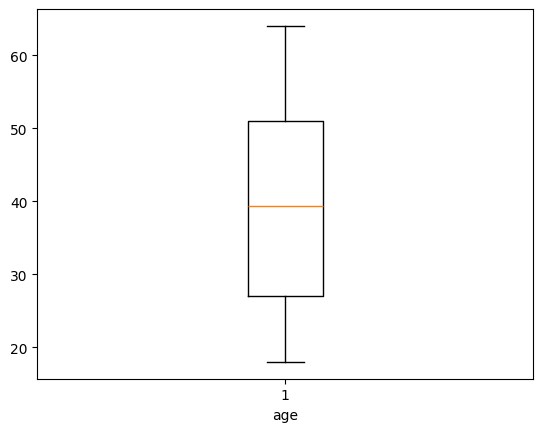

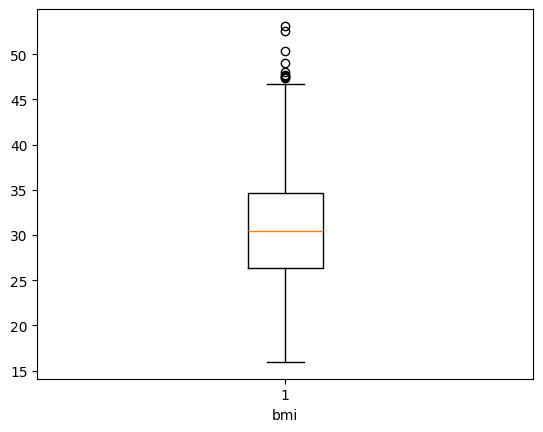

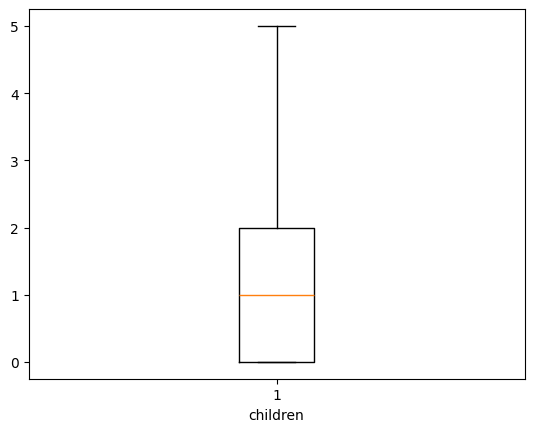

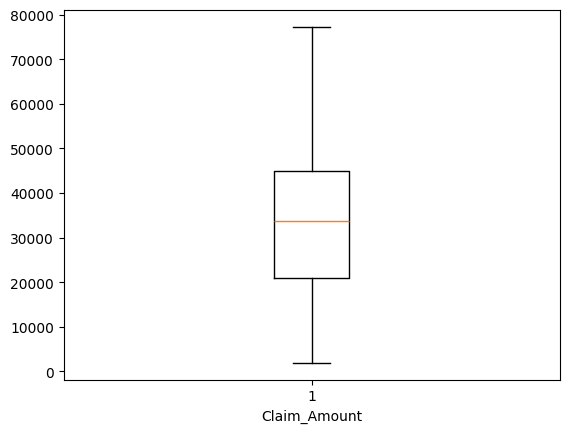

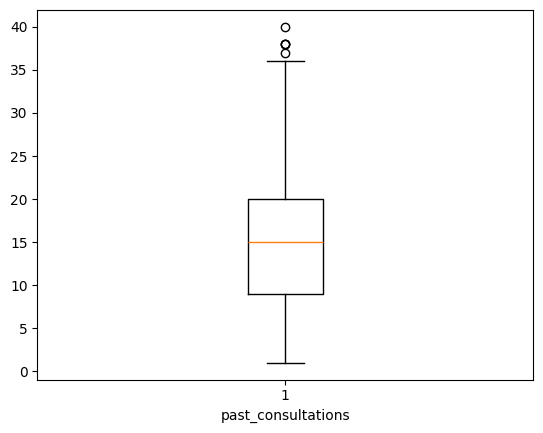

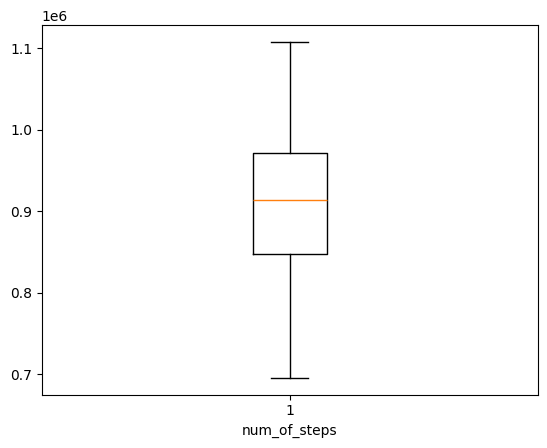

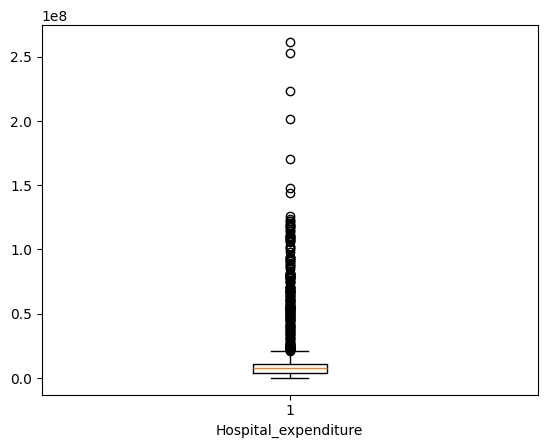

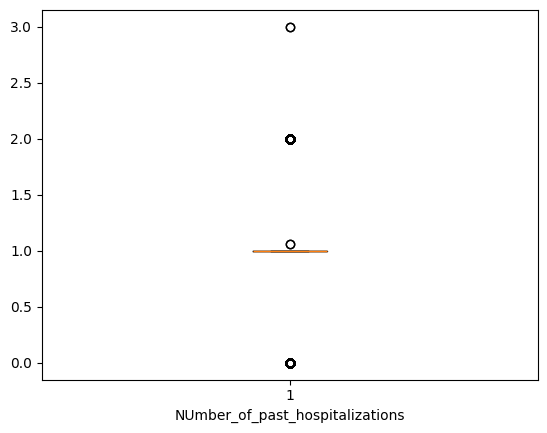

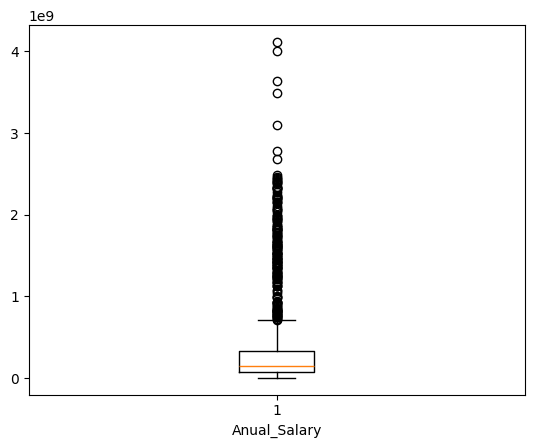

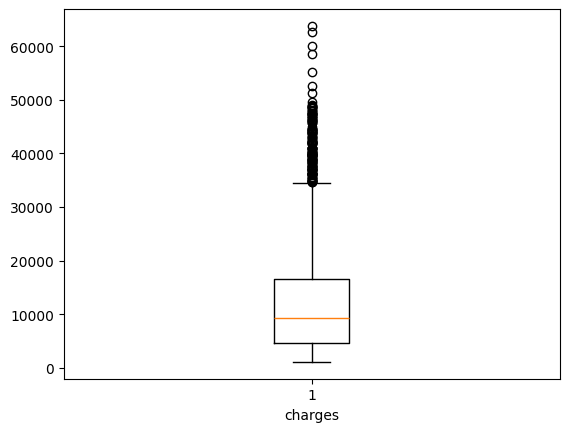

In [15]:
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

# **OUTLIERS**

In [16]:
# # Replace cell [123] with this:
# outlier_cols = ['bmi', 'Claim_Amount', 'past_consultations', 'Hospital_expenditure', 'Anual_Salary']

# for x in outlier_cols:
#     Q1 = df[x].quantile(0.25)
#     Q3 = df[x].quantile(0.75)
#     IQR = Q3 - Q1
#     lb = Q1 - 1.5 * IQR
#     ub = Q3 + 1.5 * IQR
#     df = df[(df[x] >= lb) & (df[x] <= ub)]

In [17]:
for x in df.columns:
    if df[x].dtype == 'float64' and x != 'charges':
        Q1 = df[x].quantile(0.25)
        Q3 = df[x].quantile(0.75)
        IQR = Q3 - Q1
        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR
        df = df[(df[x] >= lb) & (df[x] <= ub)]

In [18]:
# # Alternative fix for cell [123]:
# for x in df.columns:
#     if df[x].dtype == 'float64' and x != 'charges':
#         Q1 = df[x].quantile(0.25)
#         Q3 = df[x].quantile(0.75)
#         IQR = Q3 - Q1
#         if IQR == 0:
#             continue  # Skip columns where 25th and 75th percentiles are identical
#         lb = Q1 - 1.5 * IQR
#         ub = Q3 + 1.5 * IQR
#         df = df[(df[x] >= lb) & (df[x] <= ub)]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 151 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              881 non-null    float64
 1   sex                              881 non-null    object 
 2   bmi                              881 non-null    float64
 3   children                         881 non-null    float64
 4   smoker                           881 non-null    object 
 5   Claim_Amount                     881 non-null    float64
 6   past_consultations               881 non-null    float64
 7   num_of_steps                     881 non-null    float64
 8   Hospital_expenditure             881 non-null    float64
 9   NUmber_of_past_hospitalizations  881 non-null    float64
 10  Anual_Salary                     881 non-null    float64
 11  region                           881 non-null    object 
 12  charges                 

In [20]:
df.shape

(881, 13)

# **FEATURE SELECTION**

1.VIF

if vif <= 6 we are good to go

if vif > 6 remove the high vif column

2.RFE

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
col_list = []
for x in df.columns:
    if df[x].dtype != 'object' and x!='charges':
        col_list.append(x)

X = df[col_list]

vif = pd.DataFrame()
vif["Column_names"] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif

,Column_names,VIF
0,age,2.196194
1,bmi,1.052717
2,children,1.076523
3,Claim_Amount,1.035033
4,past_consultations,1.073989
5,num_of_steps,5.882074
6,Hospital_expenditure,1.173208
7,NUmber_of_past_hospitalizations,1.000000
8,Anual_Salary,3.983678


In [23]:
df.shape

(881, 13)

### **since the vif is <= 6 for each column we are good to go**

# **LETS BUILD MODEL**

In [24]:
x = df[X.columns]
y = df['charges']

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=0)

In [26]:
x_train

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
373,35.0,31.000,1.0,47511.14927,15.0,840737.0,6.969061e+06,1.0,4.423883e+07
351,34.0,25.270,1.0,35692.37968,15.0,852181.0,3.976034e+06,1.0,1.136275e+08
313,25.0,33.660,4.0,42330.32386,3.0,848234.0,3.499504e+06,1.0,3.532900e+07
730,54.0,31.240,0.0,55821.53246,17.0,912950.0,5.048570e+06,1.0,1.725900e+08
996,20.0,27.300,0.0,32076.78940,21.0,979726.0,1.012317e+07,1.0,3.500268e+08
...,...,...,...,...,...,...,...,...,...
990,38.0,19.300,0.0,47093.96209,8.0,962832.0,5.609627e+06,1.0,3.180444e+08
343,27.0,18.905,3.0,33361.32718,11.0,860149.0,6.580440e+05,1.0,4.832614e+07
783,56.0,25.935,0.0,41899.68772,20.0,940594.0,2.480337e+06,1.0,1.641562e+08
713,53.0,21.400,1.0,44031.97502,12.0,921053.0,4.111041e+06,1.0,1.330173e+08


In [27]:
x_test

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
301,28.0,22.515,2.0,15674.885110,5.0,842064.0,5.648537e+06,1.0,5.142174e+07
557,43.0,34.580,1.0,43176.571140,5.0,885104.0,2.649410e+06,1.0,1.137310e+08
665,46.0,25.745,3.0,19869.012440,11.0,900470.0,1.021216e+07,1.0,1.635565e+08
252,28.0,23.800,2.0,5579.521689,10.0,820000.0,4.963711e+06,1.0,4.472124e+07
738,54.0,39.600,1.0,34306.071490,13.0,930275.0,3.091703e+06,1.0,1.877810e+08
...,...,...,...,...,...,...,...,...,...
513,41.0,28.310,1.0,48018.271590,16.0,875244.0,7.225505e+06,1.0,1.197414e+08
518,40.0,35.300,3.0,21513.932850,7.0,896842.0,7.614067e+06,1.0,1.088563e+08
415,35.0,35.860,2.0,47705.793100,20.0,876156.0,4.781388e+06,1.0,1.315786e+08
471,41.0,32.965,0.0,12929.429980,13.0,886040.0,4.475731e+05,1.0,5.840026e+07


In [28]:
y_train

,charges
373,5240.76500
351,4894.75330
313,4504.66240
730,10338.93160
996,16232.84700
...,...
990,15820.69900
343,4827.90495
783,11165.41765
713,10065.41300


In [29]:
y_test

,charges
301,4428.88785
557,7727.25320
665,9301.89355
252,3847.67400
738,10450.55200
...,...
513,7153.55390
518,7196.86700
415,5836.52040
471,6571.02435


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [32]:
y_pred = model.predict(x_test)
y_pred

array([ 4388.41276296,  7583.37158355,  9308.55583228,  3083.16632037,
       11161.38494092, 12142.23945545, 13312.84894178, 15060.68210656,
        9306.08237821,  3142.05473881,  6281.92379336,  9888.25367852,
        7132.42497186, 16174.45621097,  9509.31945424, 12125.56074733,
        6414.62006916,  3346.62518726,  3864.17869713,  6173.85846862,
       12291.34613803,  2767.05354969,  6972.9255954 ,  5476.76856711,
       11197.92660197,  2314.50769874, 12189.13629461,  6692.81673309,
       12331.46419495,  9189.69395269, 17619.4780332 , 12410.15683062,
       18273.1033249 ,  8235.74871981, 10732.15098118, 12023.78325916,
        6716.86752178,  5086.65941905,  7278.19261676,  7070.81858719,
       10038.84286612, 10797.38546674,  5337.18335435, 10730.24630584,
        4118.0654353 ,  6467.81719179, 14238.24482503,  9829.31157367,
       11294.77216393, 12177.12518972,  3069.10682238,  5753.60077765,
        7693.75793349, 12932.06234268,  6080.65695686, 14708.17450535,
      

In [33]:
df_new = pd.DataFrame()
df_new["Actual_charges"] = y_test
df_new["Predicted_Charges"] = y_pred
df_new

,Actual_charges,Predicted_Charges
301,4428.88785,4388.412763
557,7727.25320,7583.371584
665,9301.89355,9308.555832
252,3847.67400,3083.166320
738,10450.55200,11161.384941
...,...,...
513,7153.55390,7396.398746
518,7196.86700,8035.974158
415,5836.52040,7554.200874
471,6571.02435,6683.809151


In [34]:
from sklearn.metrics import *

In [35]:
mean_squared_error(y_test,y_pred)

575632.1437661991

In [36]:
root_mean_squared_error(y_test,y_pred)

758.7042531620599

In [37]:
mean_absolute_error(y_test,y_pred)

614.9192507996577

In [38]:
r2_score(y_test,y_pred)*100

96.05264390530446

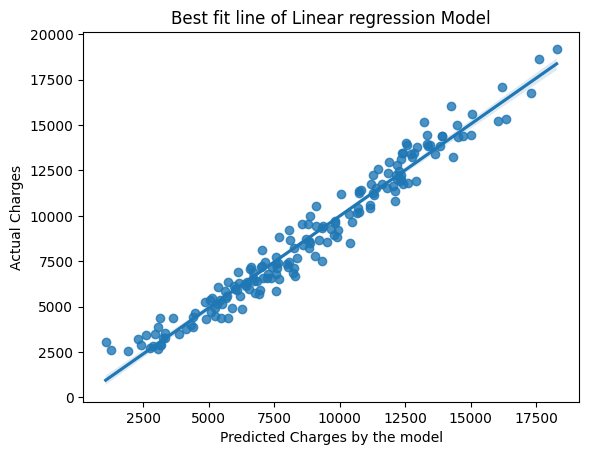

In [39]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predicted Charges by the model')
plt.ylabel('Actual Charges')
plt.title('Best fit line of Linear regression Model')
plt.show()